In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid-19-deaths-predict-conditions-contributing/Conditions_Contributing_to_COVID-19_Deaths__by_State_and_Age__Provisional_2020-2023.csv


In [5]:

df = pd.read_csv("/kaggle/input/covid-19-deaths-predict-conditions-contributing/Conditions_Contributing_to_COVID-19_Deaths__by_State_and_Age__Provisional_2020-2023.csv")
df

,Start Date,End Date,Group,Year,Month,State,Condition Group,Condition,ICD10_codes,Age Group,COVID-19 Deaths,Number of Mentions,Flag
0,1/1/2020,9/23/2023,By Total,NaN,NaN,United States,Respiratory diseases,Influenza and pneumonia,J09-J18,0-24,1569.0,1647.0,NaN
1,1/1/2020,9/23/2023,By Total,NaN,NaN,United States,Respiratory diseases,Influenza and pneumonia,J09-J18,25-34,5804.0,6029.0,NaN
2,1/1/2020,9/23/2023,By Total,NaN,NaN,United States,Respiratory diseases,Influenza and pneumonia,J09-J18,35-44,15080.0,15699.0,NaN
3,1/1/2020,9/23/2023,By Total,NaN,NaN,United States,Respiratory diseases,Influenza and pneumonia,J09-J18,45-54,37414.0,38878.0,NaN
4,1/1/2020,9/23/2023,By Total,NaN,NaN,United States,Respiratory diseases,Influenza and pneumonia,J09-J18,55-64,82668.0,85708.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620995,5/1/2023,5/31/2023,By Month,2023.0,5.0,Puerto Rico,COVID-19,COVID-19,U071,All Ages,67.0,67.0,NaN
620996,6/1/2023,6/30/2023,By Month,2023.0,6.0,Puerto Rico,COVID-19,COVID-19,U071,All Ages,122.0,122.0,NaN
620997,7/1/2023,7/31/2023,By Month,2023.0,7.0,Puerto Rico,COVID-19,COVID-19,U071,All Ages,114.0,114.0,NaN
620998,8/1/2023,8/31/2023,By Month,2023.0,8.0,Puerto Rico,COVID-19,COVID-19,U071,All Ages,78.0,78.0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621000 entries, 0 to 620999
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Start Date          621000 non-null  object 
 1   End Date            621000 non-null  object 
 2   Group               621000 non-null  object 
 3   Year                608580 non-null  float64
 4   Month               558900 non-null  float64
 5   State               621000 non-null  object 
 6   Condition Group     621000 non-null  object 
 7   Condition           621000 non-null  object 
 8   ICD10_codes         621000 non-null  object 
 9   Age Group           621000 non-null  object 
 10  COVID-19 Deaths     437551 non-null  float64
 11  Number of Mentions  443423 non-null  float64
 12  Flag                183449 non-null  object 
dtypes: float64(4), object(9)
memory usage: 61.6+ MB


In [8]:
df.describe()

,Year,Month,COVID-19 Deaths,Number of Mentions
count,608580.000000,558900.000000,4.375510e+05,4.434230e+05
mean,2021.408163,6.200000,1.201179e+02,1.293348e+02
std,1.086436,3.350625,2.980201e+03,3.203936e+03
min,2020.000000,1.000000,0.000000e+00,0.000000e+00
25%,2020.000000,3.000000,0.000000e+00,0.000000e+00
50%,2021.000000,6.000000,0.000000e+00,0.000000e+00
75%,2022.000000,9.000000,1.800000e+01,1.900000e+01
max,2023.000000,12.000000,1.146242e+06,1.146242e+06


<Axes: >

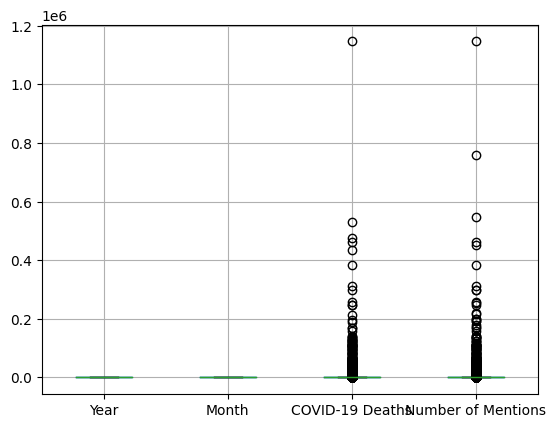

In [10]:
df.[['age']].boxplot()

In [17]:
df.isnull()

,Start Date,End Date,Group,Year,Month,State,Condition Group,Condition,ICD10_codes,Age Group,COVID-19 Deaths,Number of Mentions,Flag
0,False,False,False,True,True,False,False,False,False,False,False,False,True
1,False,False,False,True,True,False,False,False,False,False,False,False,True
2,False,False,False,True,True,False,False,False,False,False,False,False,True
3,False,False,False,True,True,False,False,False,False,False,False,False,True
4,False,False,False,True,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620995,False,False,False,False,False,False,False,False,False,False,False,False,True
620996,False,False,False,False,False,False,False,False,False,False,False,False,True
620997,False,False,False,False,False,False,False,False,False,False,False,False,True
620998,False,False,False,False,False,False,False,False,False,False,False,False,True


In [18]:
df.isnull().sum()

Start Date                 0
End Date                   0
Group                      0
Year                   12420
Month                  62100
State                      0
Condition Group            0
Condition                  0
ICD10_codes                0
Age Group                  0
COVID-19 Deaths       183449
Number of Mentions    177577
Flag                  437551
dtype: int64

In [21]:
df.Month.isnull()

0          True
1          True
2          True
3          True
4          True
          ...  
620995    False
620996    False
620997    False
620998    False
620999    False
Name: Month, Length: 621000, dtype: bool

In [ ]:
df.age.plot.chart()